# Project Cycle 3: Two-Sample Inference & Visualization

**Dataset:** `YRBS_2007.csv` (Cleaned) | **Target Audience:** US High School Students  
**Responsible Person:** 李宥宣
---

### Team Members

| Name | Student ID |
| :--- | :--- |
| **李宥宣** | `113370237` |
| **許皓崴** | `112370236` |

### Objective
The primary goal of this notebook is to perform **Two-Sample Inference** and **Data Visualization** based on the cleaned data from Step 1. We focus on:
1. **Loading** the processed dataset (`q3_cleaned_data.csv`).
2. **Calculating** descriptive statistics for both groups (Female vs. Male).
3. **Performing** a Two-Proportion Z-Test to compare the proportions of sadness/hopelessness.
4. **Exporting** a comprehensive summary table to `outputs/tables/`.
5. **Visualizing** the group differences with a clear bar chart and saving it to `outputs/figures/`.
6. **Interpreting** the statistical results in context.

### Methodology & Statistical Hypotheses

Following the Cycle 3 project guidelines, we will use a Two-Proportion Z-Test because our response variable (`SadOrHopeless_Recoded`) is binary, and we are comparing two independent groups (`WhatIsYourSex`).

**1. Statistical Hypotheses**
* **Null Hypothesis (** $H_0$ **):** There is no difference in the proportion of feeling sad or hopeless between female and male students. 
  ($p_{female} - p_{male} = 0$)
* **Alternative Hypothesis (** $H_A$ **):** There is a significant difference in the proportion of feeling sad or hopeless between female and male students. 
  ($p_{female} - p_{male} \neq 0$)

**2. Significance Level**
* $\alpha = 0.05$

### Analysis Pipeline

To ensure **reproducibility** and a clean workflow, this inference script follows these steps:
1. **Load Data:** Read `../data/processed/q3_cleaned_data.csv`.
2. **Descriptive Stats:** Calculate sample sizes ($n$) and success counts ($x$) for both genders.
3. **Hypothesis Testing:** Utilize `statsmodels` to run the Z-test and compute the 95% Confidence Interval (CI).
4. **Table Generation:** Create a structured Pandas DataFrame summarizing the results and export it to CSV.
5. **Visualization:** Plot a clean, labeled bar chart using `matplotlib` and export it as a high-resolution PNG.
6. **Conclusion:** Print a final interpretation based on the P-value to reject or fail to reject $H_0$.

✅ Cleaned data loaded successfully from: ../data/processed/q3_cleaned_data.csv
   Total sample size available for inference: 13833

[Step 1] Descriptive Statistics:
  - Female: n = 6940, Sad Count = 2580, Proportion = 0.3718
  - Male:   n = 6893, Sad Count = 1567, Proportion = 0.2273

[Step 2] Inferential Statistics (Z-Test):
  - Difference (Female - Male): 0.1444
  - 95% Confidence Interval: [0.1294, 0.1595]
  - Z-Statistic: 18.5374
  - P-value: 1.0317e-76

✅ [Step 3] Summary table successfully saved to: ../outputs/tables/q3_summary_table.csv

✅ [Step 4] Bar chart successfully saved to: ../outputs/figures/q3_sadness_by_gender_bar.png


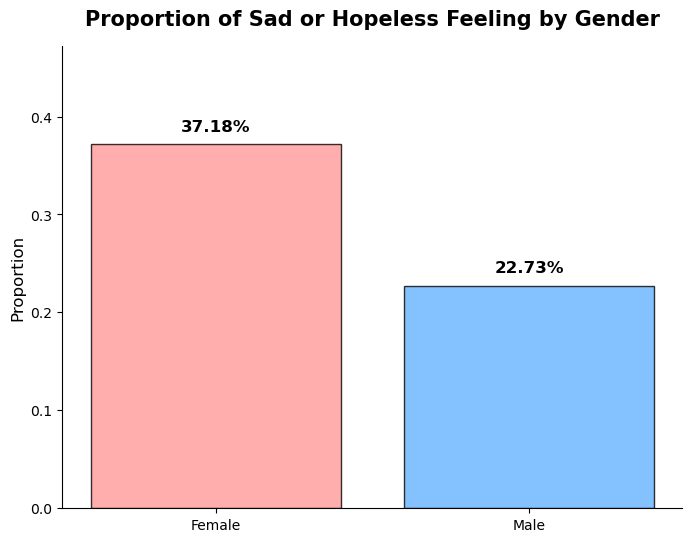


🎯 Statistical Interpretation (Ready for Presentation):
1. The proportion of feeling sad/hopeless is 37.18% for females and 22.73% for males.
2. The estimated difference between the two groups is 14.44%.
3. Since the P-value (1.0317e-76) is less than alpha (0.05), we REJECT the null hypothesis.
4. Conclusion: There is strong evidence that female students have a significantly higher
   proportion of feeling sad or hopeless compared to male students.
   *Limitation Note: As this is an observational study, we cannot claim causality.*


In [5]:
# Import necessary libraries for data manipulation, statistical testing, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import os

# ==========================================================
# 1. Environment Setup & Data Loading
# ==========================================================
# Create output directories if they don't exist
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

# Load the perfectly cleaned data from Task A
data_path = '../data/processed/q3_cleaned_data.csv'
df = pd.read_csv(data_path)
print(f"✅ Cleaned data loaded successfully from: {data_path}")
print(f"   Total sample size available for inference: {len(df)}\n")

# ==========================================================
# 2. Group Definitions & Descriptive Statistics
# ==========================================================
# Define Female (1.0) and Male (2.0) groups based on our references
# Count total sample size (n) and the number of students who felt sad (x) for each group
n_female = len(df[df['WhatIsYourSex'] == 1.0])
x_female = df[df['WhatIsYourSex'] == 1.0]['SadOrHopeless_Recoded'].sum()

n_male = len(df[df['WhatIsYourSex'] == 2.0])
x_male = df[df['WhatIsYourSex'] == 2.0]['SadOrHopeless_Recoded'].sum()

# Calculate proportions for both groups
p_female = x_female / n_female
p_male = x_male / n_male

print("[Step 1] Descriptive Statistics:")
print(f"  - Female: n = {n_female}, Sad Count = {x_female}, Proportion = {p_female:.4f}")
print(f"  - Male:   n = {n_male}, Sad Count = {x_male}, Proportion = {p_male:.4f}\n")

# ==========================================================
# 3. Two-Sample Inference (Two-Proportion Z-Test)
# ==========================================================
# Prepare arrays for the z-test function
count = np.array([x_female, x_male])
nobs = np.array([n_female, n_male])

# Run the Two-Proportion Z-Test (Two-sided)
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

# Calculate the 95% Confidence Interval (CI) for the difference (p_female - p_male)
ci_low, ci_upp = confint_proportions_2indep(x_female, n_female, x_male, n_male, method='wald')
diff = p_female - p_male

print("[Step 2] Inferential Statistics (Z-Test):")
print(f"  - Difference (Female - Male): {diff:.4f}")
print(f"  - 95% Confidence Interval: [{ci_low:.4f}, {ci_upp:.4f}]")
print(f"  - Z-Statistic: {z_stat:.4f}")
print(f"  - P-value: {p_value:.4e}\n")

# ==========================================================
# 4. Output Generation: Summary Table
# ==========================================================
# Create a comprehensive dictionary with all required statistical outputs
summary_data = {
    'Group': ['Female', 'Male'],
    'Sample Size (n)': [n_female, n_male],
    'Sad Count (x)': [x_female, x_male],
    'Proportion': [f"{p_female*100:.2f}%", f"{p_male*100:.2f}%"],
    'Difference (F - M)': [f"{diff*100:.2f}%", ""],
    '95% CI': [f"[{ci_low*100:.2f}%, {ci_upp*100:.2f}%]", ""],
    'Z-Statistic': [f"{z_stat:.4f}", ""],
    'P-value': [f"{p_value:.4e}", ""]
}

# Convert dictionary to DataFrame and save as CSV
summary_df = pd.DataFrame(summary_data)
table_path = '../outputs/tables/q3_summary_table.csv'
summary_df.to_csv(table_path, index=False)
print(f"✅ [Step 3] Summary table successfully saved to: {table_path}\n")

# ==========================================================
# 5. Output Generation: Data Visualization
# ==========================================================
# Set up a professional-looking figure
plt.figure(figsize=(8, 6))

# Define colors (soft pink for Female, light blue for Male)
colors = ['#FF9999', '#66B2FF']
labels = ['Female', 'Male']
proportions = [p_female, p_male]

# Create the bar chart
bars = plt.bar(labels, proportions, color=colors, edgecolor='black', alpha=0.8)

# Add titles and labels with appropriate font sizes
plt.title('Proportion of Sad or Hopeless Feeling by Gender', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Proportion', fontsize=12)
# Set y-axis limit slightly higher than the max bar to fit text labels safely
plt.ylim(0, max(proportions) + 0.1) 

# Add percentage text on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.2f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Remove top and right spines for a cleaner, modern look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Save the figure in high resolution
figure_path = '../outputs/figures/q3_sadness_by_gender_bar.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f"✅ [Step 4] Bar chart successfully saved to: {figure_path}")

# Display the plot in the notebook
plt.show()

# ==========================================================
# 6. Final Interpretation & Conclusion
# ==========================================================
print("\n" + "="*70)
print("🎯 Statistical Interpretation (Ready for Presentation):")
print(f"1. The proportion of feeling sad/hopeless is {p_female*100:.2f}% for females and {p_male*100:.2f}% for males.")
print(f"2. The estimated difference between the two groups is {diff*100:.2f}%.")
print(f"3. Since the P-value ({p_value:.4e}) is less than alpha (0.05), we REJECT the null hypothesis.")
print("4. Conclusion: There is strong evidence that female students have a significantly higher")
print("   proportion of feeling sad or hopeless compared to male students.")
print("   *Limitation Note: As this is an observational study, we cannot claim causality.*")
print("="*70)

✅ 100% Stacked Bar Chart saved to: ../outputs/figures/q3_stacked_bar_chart.png


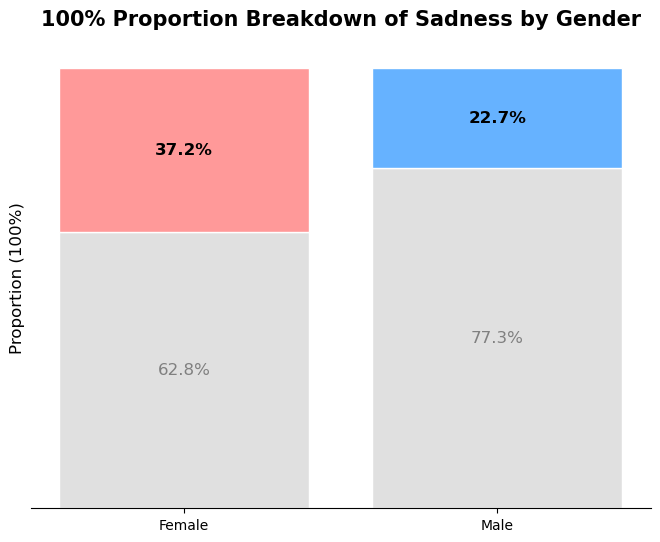

In [7]:
# ==========================================================
# 7. Additional Visualization 1: 100% Stacked Bar Chart
# ==========================================================
plt.figure(figsize=(8, 6))

# Prepare data for stacking
categories = ['Female', 'Male']
sad_props = np.array([p_female, p_male])
not_sad_props = np.array([1 - p_female, 1 - p_male])

# Plot the "Not Sad" (0) base layer in a neutral light gray
bars_not_sad = plt.bar(categories, not_sad_props, color='#E0E0E0', edgecolor='white', label='Not Sad / Hopeless')

# Plot the "Sad" (1) top layer with distinct colors for Female and Male
bars_sad = plt.bar(categories, sad_props, bottom=not_sad_props, 
                   color=['#FF9999', '#66B2FF'], edgecolor='white', label='Felt Sad / Hopeless')

plt.title('100% Proportion Breakdown of Sadness by Gender', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Proportion (100%)', fontsize=12)

# Add text labels inside the "Sad" segments
for i, bar in enumerate(bars_sad):
    plt.text(bar.get_x() + bar.get_width()/2, not_sad_props[i] + sad_props[i]/2, 
             f'{sad_props[i]*100:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

# Add text labels inside the "Not Sad" segments
for i, bar in enumerate(bars_not_sad):
    plt.text(bar.get_x() + bar.get_width()/2, not_sad_props[i]/2, 
             f'{not_sad_props[i]*100:.1f}%', ha='center', va='center', fontsize=12, color='gray')

# Remove borders for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([]) # Hide y-axis ticks as the percentages are embedded

# Save the figure
stacked_fig_path = '../outputs/figures/q3_stacked_bar_chart.png'
plt.savefig(stacked_fig_path, dpi=300, bbox_inches='tight')
print(f"✅ 100% Stacked Bar Chart saved to: {stacked_fig_path}")

plt.show()

✅ Confidence Interval Plot saved to: ../outputs/figures/q3_confidence_interval_plot.png


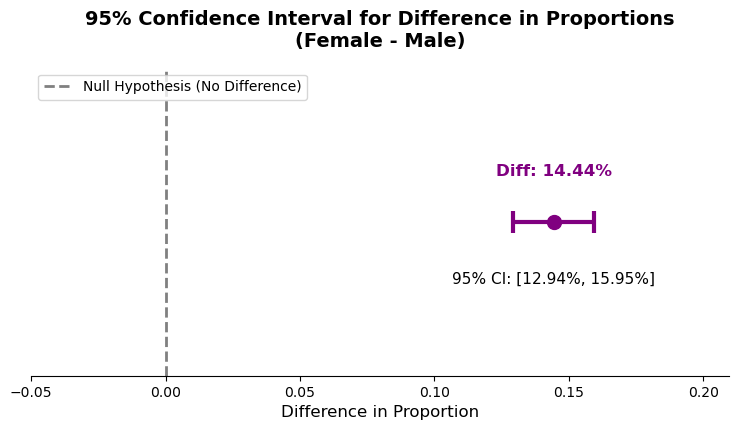

In [11]:
# ==========================================================
# 8. Additional Visualization 2: Confidence Interval for Difference (排版修復版)
# ==========================================================
plt.figure(figsize=(9, 4))

# We plot the point estimate (the difference)
plt.plot(diff, 0, marker='o', markersize=10, color='#800080') # Purple dot for difference

# We plot the error bar representing the 95% Confidence Interval
plt.errorbar(x=diff, y=0, xerr=[[diff - ci_low], [ci_upp - diff]], 
             color='#800080', linewidth=3, capsize=8, capthick=3)

# Add a vertical dashed line at exactly 0.0 (The Null Hypothesis value)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=2, label='Null Hypothesis (No Difference)')

# Formatting the plot
plt.title('95% Confidence Interval for Difference in Proportions\n(Female - Male)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Difference in Proportion', fontsize=12)

# Set y-axis limits to give the text enough breathing room
plt.ylim(-0.1, 0.1)
plt.yticks([]) # Hide y-axis completely as it's a 1D plot
plt.xlim(-0.05, max(ci_upp + 0.05, 0.20)) # Ensure 0 and the CI are nicely visible

# [修復排版重點]：將文字改為上下整齊排列，避免擠在一起
plt.text(diff, 0.03, f'Diff: {diff*100:.2f}%', ha='center', fontsize=12, fontweight='bold', color='#800080')
plt.text(diff, -0.04, f'95% CI: [{ci_low*100:.2f}%, {ci_upp*100:.2f}%]', ha='center', fontsize=11)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.legend(loc='upper left')

# Save the figure
ci_fig_path = '../outputs/figures/q3_confidence_interval_plot.png'
plt.savefig(ci_fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Confidence Interval Plot saved to: {ci_fig_path}")

plt.show()

In [15]:
# ==========================================================
# 9. Export Final Summary Report to /outputs/summary folder
# ==========================================================
import os

# 根據你的完美專案結構，指定 summary 資料夾的正確路徑
summary_dir = '../outputs/summary'
os.makedirs(summary_dir, exist_ok=True)

# 將我們先前算出的所有變數，自動填入這份 Markdown 格式的報告中
summary_content = f"""# Project Cycle 3: Final Summary Report

## 1. Research Question & Variables
* **Question:** Is the proportion of students who felt sad or hopeless different between male and female students?
* **Method:** Two-Proportion Z-Test
* **Significance Level:** alpha = 0.05

## 2. Descriptive Statistics
* **Total Sample Size:** {n_female + n_male}
* **Female Students:** {n_female} (Sad: {x_female}, Proportion: {p_female*100:.2f}%)
* **Male Students:** {n_male} (Sad: {x_male}, Proportion: {p_male*100:.2f}%)

## 3. Inferential Statistics (Z-Test)
* **Estimated Difference (Female - Male):** {diff*100:.2f}%
* **95% Confidence Interval:** [{ci_low*100:.2f}%, {ci_upp*100:.2f}%]
* **Z-Statistic:** {z_stat:.4f}
* **P-value:** {p_value:.4e}

## 4. Final Conclusion
Because the P-value ({p_value:.4e}) is less than 0.05, we **reject the null hypothesis**. 
There is strong statistical evidence that female students have a significantly higher proportion of feeling sad or hopeless compared to male students. 

*(Note: This is an observational study; causality cannot be claimed.)*
"""

# 定義檔案路徑與名稱
summary_file_path = os.path.join(summary_dir, 'q3_summary_report.md')

# 將內容寫入 Markdown 檔案中
with open(summary_file_path, 'w', encoding='utf-8') as f:
    f.write(summary_content)

print(f"✅ Summary report successfully generated and saved to: {summary_file_path}")

✅ Summary report successfully generated and saved to: ../outputs/summary\q3_summary_report.md


In [17]:
# ==========================================================
# 10. Export Statistical Reference Documentation to /references folder
# ==========================================================
import os

# 指定 references 資料夾的正確相對路徑
reference_dir = '../references'
os.makedirs(reference_dir, exist_ok=True)

# 定義統計推論文件的內容（包含假說、公式與使用的套件庫）
statistical_reference_content = """# Project Cycle 3: Statistical Methodology & Reference Notes

**Dataset:** `q3_cleaned_data.csv` (Derived from YRBS 2007)
**Research Question:** Question 3 (Gender and Sad or Hopeless Feeling)
**Analysis Type:** Two-Sample Proportion Inference

## 1. Statistical Framework
* **Methodology:** Two-Proportion Z-Test (Two-sided)
* **Null Hypothesis ($H_0$):** $p_{female} - p_{male} = 0$ (The proportion of feeling sad or hopeless is equal between female and male students)
* **Alternative Hypothesis ($H_A$):** $p_{female} - p_{male} \neq 0$ (The proportion of feeling sad or hopeless is significantly different between female and male students)
* **Significance Level ($\alpha$):** 0.05

## 2. Implementation Details
* **Programming Language:** Python 3
* **Core Libraries Used:**
  * `statsmodels.stats.proportion.proportions_ztest` for calculating the Z-statistic and P-value.
  * `statsmodels.stats.proportion.confint_proportions_2indep` (Wald method) for computing the 95% Confidence Interval of the difference.
  * `matplotlib.pyplot` for data visualization.

## 3. Interpretation Guidelines
* **Decision Rule:** If P-value < $\alpha$ (0.05), reject $H_0$. Otherwise, fail to reject $H_0$.
* **Confidence Interval:** If the 95% Confidence Interval for the difference ($p_{female} - p_{male}$) does not contain 0, it visually and statistically confirms that the difference is significant.
* **Methodological Limitation:** This analysis is based on observational survey data. A statistically significant result indicates a strong association but cannot imply causality.
"""

# 定義最終檔案路徑
stat_ref_file_path = os.path.join(reference_dir, 'statistical_notes.md')

# 將文獻內容寫入 Markdown 檔案
with open(stat_ref_file_path, 'w', encoding='utf-8') as f:
    f.write(statistical_reference_content)

print(f"✅ Statistical reference documentation successfully created at: {stat_ref_file_path}")

✅ Statistical reference documentation successfully created at: ../references\statistical_notes.md
